## Partial Differentiation

In [2]:
import numpy as np
import matplotlib.pyplot as plt

One of the most important ideas in physics is taking the gradient. We've all seen: $$\vec{F} = -\nabla U $$
For now, let's plot a function of two variables:
$$U(x,y) = \frac{1}{2}k_xx^2 + \frac{1}{2}k_yy^2 + \alpha xy $$

In [15]:
kx = 2.0
ky = 4.0
alpha = 1.0

def U(x, y):  #def allows us to define a funcion in python.
   return 0.5*kx*x**2 + 0.5*ky*y**2 + alpha*x*y

x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)

X, Y = np.meshgrid(x, y)  #meshgrid here creates a

##Z = 0.5*kx*X**2 + 0.5*ky*Y**2 + alpha*X*Y  ---> if you choose to not use def U(x,y)
Z = U(X,Y)

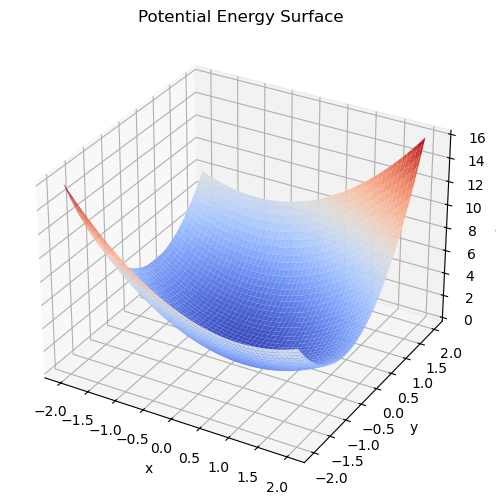

In [23]:
#plotting 3d
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")  #makes it 3D

ax.plot_surface(X, Y, Z, cmap='coolwarm') #many different cmap colors you can play with

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("U(x,y)")
ax.set_title("Potential Energy Surface")

plt.show()

## Countour Plots

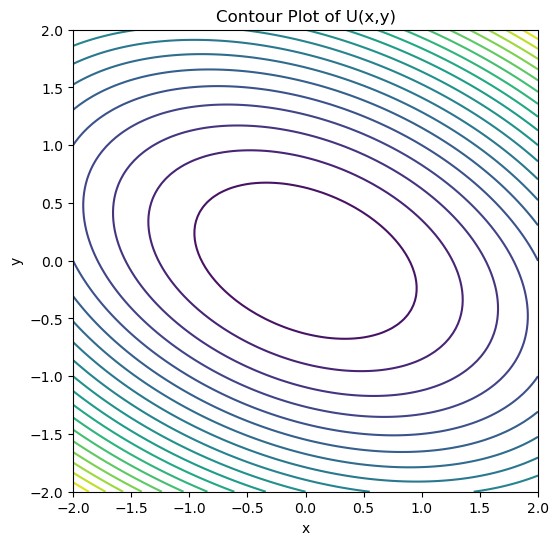

In [26]:
plt.figure(figsize=(6, 6))

plt.contour(X, Y, Z, levels=20)  

plt.xlabel("x")
plt.ylabel("y")
plt.title("Contour Plot of U(x,y)")

plt.show()

## Partial Derivatives
$$U(x,y) = \frac{1}{2}k_xx^2 + \frac{1}{2}k_yy^2 + \alpha xy $$
$$\frac{\partial U}{\partial x} = k_xx + \alpha y $$

$$\frac{\partial U}{\partial y} = k_y y^2 + \alpha x $$
so,
$$\nabla U = \frac{\partial U}{\partial x}\hat x + \frac{\partial U}{\partial y}\hat y $$
Let's define these functions in python

In [28]:
#defining functions helps keep a lot of code clearer in my opinion
def dU_dx(x, y):
    return kx*x + alpha*y

def dU_dy(x, y):
    return ky*y + alpha*x

To evaluate the gradient at a point:

In [34]:
x0 = 1.0
y0 = 0.5

grad_U = np.array([dU_dx(x0, y0), dU_dy(x0, y0)])

print("Gradient at point:", grad_U)

Gradient at point: [2.5 3. ]


Plotting the gradient:

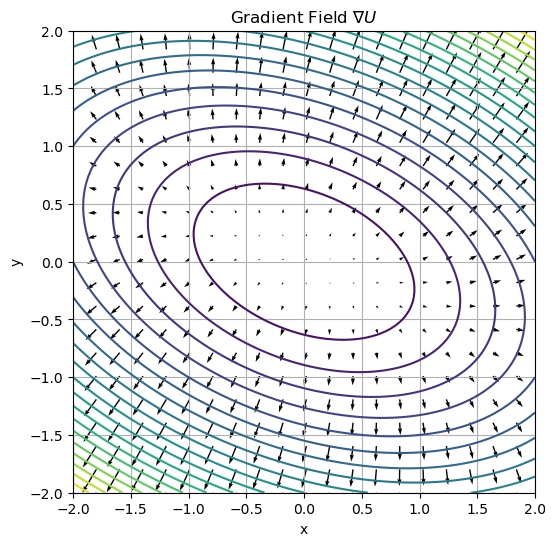

In [36]:
dUdx = dU_dx(X, Y)
dUdy = dU_dy(X, Y)

plt.figure(figsize=(6, 6))

plt.contour(X, Y, Z, levels=20)
plt.quiver(X[::5, ::5], Y[::5, ::5],  #plots the arrows. 
           dUdx[::5, ::5], dUdy[::5, ::5])  #:: using both rows of the array.
                                            #so it takes data every 5th element of both
                                            #rows and columns

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Gradient Field $\nabla U$")
plt.grid()
plt.gca().set_aspect("equal")

plt.show()

## Force
Since,  $$\vec{F} = -\nabla U $$
then, $$F_x = - \frac{\partial U}{\partial x}$$
and, $$F_y = - \frac{\partial U}{\partial y}$$

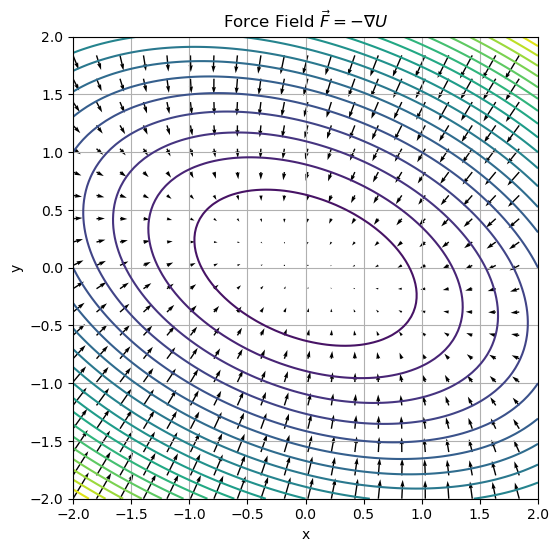

In [41]:
#same code as above with difference being the negative sign
Fx = -dUdx
Fy = -dUdy

plt.figure(figsize=(6, 6))

plt.contour(X, Y, Z, levels=20)
plt.quiver(X[::5, ::5], Y[::5, ::5],
           Fx[::5, ::5], Fy[::5, ::5])

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Force Field $\vec{F} = -\nabla U$")
plt.grid()

plt.show()

## Numerical Derivatives
Derivatives can be approximated using the the method of finite differences. There are different finite difference methods such as forward difference, backward difference, and central difference. We will be using the central one since it tends to be mroe accurate than the others: 
$$\frac{dF}{dx}  = \frac{F(x+h) - F(x-h)}{2h}$$



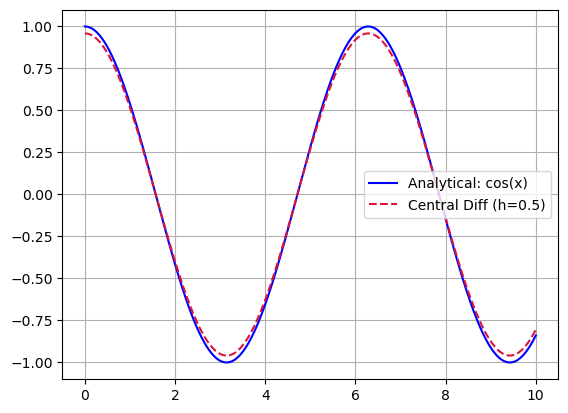

In [60]:
#Define your funcition
def my_function(x):
    return np.sin(x)
    
#defining numerical deriative
def numerical_derivative(f, x, h):
    return (f(x+h) - f(x-h)) / (2*h)

x = np.linspace(0, 10, 1000)
df = numerical_derivative(my_function, x, h=0.5)

plt.plot(x, np.cos(x), label='Analytical: cos(x)', color='blue')
plt.plot(x, df, '--', label='Central Diff (h=0.5)', color='crimson')
plt.legend()
plt.grid(True)
plt.show()



The x partial deritavie can be approximated as: 
$$\frac{\partial U}{\partial x}  = \frac{U(x+h,y) - U(x-h, y)}{2h}$$
where h is the step size. For the y partial: 
$$\frac{\partial U}{\partial y}  = \frac{U(x,y+h) - U(x, y-h)}{2h}$$

In [66]:
def numerical_dU_dx(x, y, h=1e-5): #the smaller the h, the more accurate
    return (U(x+h, y) - U(x-h, y)) / (2*h)

def numerical_dU_dy(x, y, h=1e-5):
    return (U(x, y+h) - U(x, y-h)) / (2*h)

In [67]:
x0 = 1.0
y0 = 0.5

print("Analytical dU/dx:", dU_dx(x0, y0))
print("Numerical dU/dx:", numerical_dU_dx(x0, y0))

print("Analytical dU/dy:", dU_dy(x0, y0))
print("Numerical dU/dy:", numerical_dU_dy(x0, y0))

Analytical dU/dx: 2.5
Numerical dU/dx: 2.4999999999941735
Analytical dU/dy: 3.0
Numerical dU/dy: 2.9999999999974487
